# Free JJ conserved-current correlators (L=4, Nt=128)

L=4 counterpart of `jj_free_correlators_claude.ipynb` (L=1) / `..._L2_claude.ipynb` (L=2) -- same panels.
Methods at L=4:
- `exact` -- STOCHASTIC full conserved current $K$ (resolvent-dressed; `jj_corr_L4`, non-blocked).
  Stored as **per-hit files** `corr.<k>.h<h>.h5` (one hit each, data under `h0/`); `.tmp` = in-progress.
- `local` -- ultralocal $\hat e\cdot\sigma$ current + lattice $P=D_\text{ov}^{-1}$ (A100 deter, method B).
- `cont`  -- local current + continuum $G$: **blocked at L=4** (cont-vs-lattice convention mismatch), so absent.

Key question (sp sign): does the EXACT sp correlator sign stay $+$ (as at L=1, L=2 -- the coarse-lattice
cutoff artifact) or flip to $-$ (the CFT side) as the cutoff shrinks at L=4?

CFT (Eq. 4.31/4.28): $C_c^{tp}=-C_J f$, $C_c^{sp}=(D-1)C_J f$, ratio $C_c^{sp}/C_c^{tp}=-(D-1)=-2$.

In [1]:
import h5py, numpy as np, matplotlib.pyplot as plt, os, glob

ESN = "data_free_vmRe0.000000vmIm0.000000"
L   = 4
# exact = STOCHASTIC K. At L=4 it is written as PER-HIT FILES corr.<k>.h<h>.h5 (one hit each, data under
# h0/); we point "exact" at the DIRECTORY and read every completed per-hit file.
def _ncomplete(d):
    return len([f for f in glob.glob(os.path.join(d,"corr.*.h*.h5")) if not f.endswith(".tmp")])
_exact_dirs = sorted(glob.glob(f"{ESN}/corr_nt0*_nhits*_L{L}"))
_exact = max(_exact_dirs, key=_ncomplete) if _exact_dirs else f"{ESN}/corr_nt02_nhits16_L{L}"
FILES = {
    "exact" : _exact,                                        # DIRECTORY of per-hit files
    "local" : f"{ESN}/corr_deter_local_L{L}/corr.0.h5",      # ultralocal e.sigma current + lattice P
    "cont"  : f"{ESN}/corr_deter_local_cont_L{L}/corr.0.h5", # local + continuum G (blocked at L=4 -> absent)
}
STOCH = {"exact"}          # statistical (per-hit) error; the rest are exact (LU) -> no error
Nt = 128

def _cx(f, key):
    return f[key+"/real"][()] + 1j*f[key+"/imag"][()]

def load_hits(path, proj, origin="t0_0"):
    # per-hit Vpp samples -> (nhits, Nt). Handles BOTH layouts:
    #  - path is a DIRECTORY  : per-hit files corr.<k>.h<h>.h5, one hit each under h0/ (skip *.tmp / incomplete)
    #  - path is a single FILE: per-hit groups h0/,h1/,... (or a single h0/ for the deterministic methods)
    out = []
    if os.path.isdir(path):
        for f in sorted(glob.glob(os.path.join(path, "corr.*.h*.h5"))):
            if f.endswith(".tmp"): continue
            try:
                with h5py.File(f, "r") as h:
                    if not h.get("complete"): continue
                    k = f"h0/{origin}/{proj}/Vpp"
                    if (k+"/real") in h: out.append(_cx(h, k))
            except Exception:
                continue
        return np.array(out) if out else None
    if not os.path.exists(path): return None
    with h5py.File(path, "r") as f:
        hs = sorted([k for k in f.keys() if k.startswith("h") and k[1:].isdigit()],
                    key=lambda s: int(s[1:]))
        for hg in hs:
            k = f"{hg}/{origin}/{proj}/Vpp"
            if (k+"/real") in f: out.append(_cx(f, k))
    return np.array(out) if out else None

def load_corr(path, proj, origin="t0_0"):
    H = load_hits(path, proj, origin)
    return None if H is None else H.mean(0)

def connected(g, lo=40, hi=80):
    if g is None: return None
    return g - np.mean(g[lo:hi])

def mean_sem(samples):
    n = samples.shape[0]
    m = samples.mean(0)
    s = samples.std(0, ddof=1) / np.sqrt(n) if n > 1 else np.full(samples.shape[1], np.nan)
    return m, s

def errbar_signed(ax, x, m, e, label, **kw):
    # error-bar markers, NO line, + branch (^) and - branch (v) split. NaN-safe (1 hit -> no bars).
    m = np.asarray(m); e = np.asarray(e, dtype=float)
    ye = None if np.all(np.isnan(e)) else e
    pos = m > 0; neg = m < 0
    if pos.any():
        ax.errorbar(x[pos], m[pos], yerr=None if ye is None else ye[pos], ls="none", marker="^",
                    ms=5, capsize=2, label=label+" (+)", **kw)
    if neg.any():
        ax.errorbar(x[neg], m[neg], yerr=None if ye is None else ye[neg], ls="none", marker="v",
                    ms=5, capsize=2, label=label+" (-)", **kw)

print("exact dir:", _exact)
print("present:", {k: (os.path.isdir(v) or os.path.exists(v)) for k,v in FILES.items()})
for key in STOCH:
    H = load_hits(FILES[key], "tp")
    print(f"{key}: {0 if H is None else H.shape[0]} completed hit(s)"
          + ("  (need >=2 hits for error bars)" if (H is not None and H.shape[0]<2) else ""))

exact dir: data_free_vmRe0.000000vmIm0.000000/corr_nt02_nhits16_L4
present: {'exact': True, 'local': True, 'cont': False}
exact: 1 completed hit(s)  (need >=2 hits for error bars)


## Raw correlators: signed Re / Im (symlog y)
Plots the actual $\pm$ real and imaginary parts (not $|C_c|$); symlog shows sign + the many decades.

`local` is exact (LU) -> line. `exact` is STOCHASTIC -> error-bar markers, no line, with the
+ branch ($\blacktriangle$) and - branch ($\blacktriangledown$) split. Errors = standard error over the
completed per-hit files. (`cont` blocked at L=4.)

In [ ]:
def plot_reim(proj, linthresh=1e-12):
    dd = np.arange(1, Nt//2)
    fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
    for key,p in FILES.items():
        if key in STOCH:
            H = load_hits(p, proj)                       # (nhits, Nt) per-hit samples
            if H is not None:
                for j,part in enumerate([H.real, H.imag]):
                    m,e = mean_sem(part)
                    errbar_signed(ax[j], dd, m[1:Nt//2], e[1:Nt//2], key)
                continue
            g = load_corr(p, proj)                       # fallback: combined file, no error bars
            if g is None: continue
            ax[0].plot(dd, g[1:Nt//2].real, ls="none", marker="x", ms=4, label=key+" (1 file)")
            ax[1].plot(dd, g[1:Nt//2].imag, ls="none", marker="x", ms=4, label=key+" (1 file)")
            continue
        g = load_corr(p, proj)
        if g is None: continue
        ax[0].plot(dd, g[1:Nt//2].real, marker=".", ms=4, label=key)
        ax[1].plot(dd, g[1:Nt//2].imag, marker=".", ms=4, label=key)
    for a,t in zip(ax, [f"Re C_c[{proj}](dt)", f"Im C_c[{proj}](dt)"]):
        a.set_yscale("symlog", linthresh=linthresh)
        a.axhline(0, color="k", lw=.6)
        a.set_xlabel("dt"); a.set_title(f"free L={L}  {t} (raw, signed)")
        a.legend(); a.grid(alpha=.3, which="both")
    plt.tight_layout(); plt.show()

plot_reim("tp")
plot_reim("sp")

## Connected (plateau-subtracted) tp & sp shapes, normalized to $dt=1$
`exact` (stochastic) overlaid with error bars; `local` as a line. Normalizing to $dt=1$ removes the
per-method overall scale, comparing shapes directly.

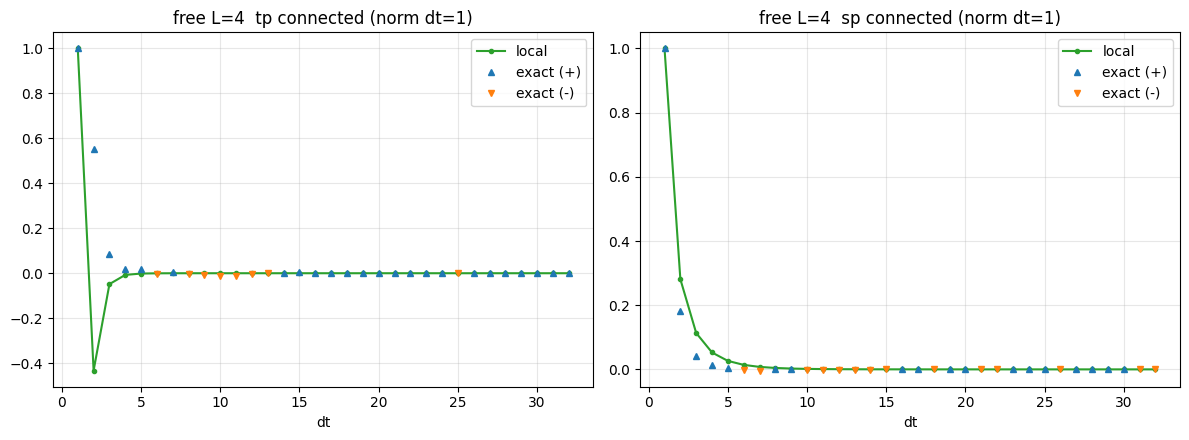

In [3]:
ds = np.arange(1,33)
fig,ax = plt.subplots(1,2,figsize=(12,4.5))
for key,p in FILES.items():
    for j,proj in enumerate(["tp","sp"]):
        if key in STOCH:
            H = load_hits(p, proj)
            if H is not None:
                # connect + normalize to dt=1 PER HIT (ratio of correlated quantities), then mean/sem
                C = H - H[:,40:80].mean(1, keepdims=True)
                R = (C / C[:,1:2]).real                 # (nhits, Nt)
                m,e = mean_sem(R)
                errbar_signed(ax[j], ds, m[ds], e[ds], key)
                continue
        c = connected(load_corr(p, proj))
        if c is not None:
            ax[j].plot(ds, (c/c[1]).real[ds], marker=".", label=key)
for a,t in zip(ax,["tp connected (norm dt=1)","sp connected (norm dt=1)"]):
    a.set_xlabel("dt"); a.set_title(f"free L={L}  {t}"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## $C_c^{sp}/C_c^{tp}$ ratio
CFT prediction: flat $-(D-1)=-2$. `exact` via per-hit ratio (error bars); `local` as a line.
At L=4 the cutoff is smallest -- the test of whether `exact` sp has moved toward the CFT ($-$) side.

In [ ]:
ds = np.arange(1,17)
plt.figure(figsize=(7.5,4.5)); ax = plt.gca()
for key,p in FILES.items():
    if key in STOCH:
        Ht = load_hits(p, "tp"); Hs = load_hits(p, "sp")
        if Ht is not None and Hs is not None:
            gt = Ht - Ht[:,40:80].mean(1, keepdims=True)
            gs = Hs - Hs[:,40:80].mean(1, keepdims=True)
            with np.errstate(divide="ignore", invalid="ignore"):
                R = (gs/gt).real                          # per-hit ratio (nhits, Nt), correlations kept
            m,e = mean_sem(R)
            errbar_signed(ax, ds, m[ds], e[ds], key)
            print(f"{key:5s} C_c[sp]/C_c[tp] dt=1..6:", [f"{m[d]:+.2f}+-{e[d]:.2f}" for d in range(1,7)])
            continue
    gt = connected(load_corr(p,"tp")); gs = connected(load_corr(p,"sp"))
    if gt is None or gs is None: continue
    with np.errstate(divide="ignore", invalid="ignore"):
        r = (gs/gt).real
    ax.plot(ds, r[ds], marker="o", ms=4, label=f"C_c[sp]/C_c[tp] ({key})")
    print(f"{key:5s} C_c[sp]/C_c[tp] dt=1..6:", [round(float(r[d]),3) for d in range(1,7)])
ax.axhline(-2, color="k", ls="--", label="CFT  -(D-1) = -2")
ax.set_xlabel("dt"); ax.set_ylabel("C_c[sp]/C_c[tp]"); ax.set_title(f"free L={L}  C_c[sp]/C_c[tp] (all methods)")
ax.set_ylim(-30,30); ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()